# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Azkia Wahtilafinnahri
- **Email:** Azkiawahtilafinnahri@gmail.com
- **ID Dicoding:** azkiajeon

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk  mana yang sering dan paling jarang dibeli customer?
- **Pertanyaan 2:** Berapa rata-rata jumlah produk dalam satu pesanan?
- .**Pertanyaan 3:**Berapa rata-rata total nilai transaksi  dalam satu pesanan setiap bulan? 

## Import Semua Packages/Library yang Digunakan

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [110]:
orders = pd.read_csv('orders_dataset.csv')
items = pd.read_csv('order_items_dataset.csv')
products = pd.read_csv('products_dataset.csv')
category = pd.read_csv('product_category_name_translation.csv')

In [111]:
#rename category
products = products.merge(category, on='product_category_name', how='left')
products.rename(columns={'product_category_name_english': 'category'}, inplace=True)

**Insight:** 
- Dataset berhasil dimuat karena berada dalam 1 folder yang sama 
- Dataset yang dimuat adalah orders, order_items, products, dan category translation

### Assessing Data

#### Identifying dataset orders problem

In [112]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [113]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [114]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

#### Identifying dataset items problem

In [115]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [116]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [117]:
items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

#### Identifying dataset products problem

In [118]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [119]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
 9   category                    32328 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


In [120]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
category                      623
dtype: int64

#### Identifying dataset category problem

In [121]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [122]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [123]:
category.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

**Steps to Take:**
- Terdapat mising value di dalam dataset orders di kolom "order_approved_at", "order_delivered_carrier_date", dan "order_delivered_customer_date" sehingga perlu dicleaning  agar hasil analisis tidak bias. atribut 'order_approved_at' dan 'order_delivered_carrier_date' masih ada yang kosong juga akan di drop juga karena pada atribut  'order_approved_at' yang kosong bisa jadi terjadi karena order belum di upload atau ada missing logs, begitu juga ppada atribut 'order_delivered_carrier_date' bisa jadi barang belum diserahkan kepada kurir.
- Terdapat banyak missing value di dalam dataset products. karena hanya fokus pada kategori sehingga hanya data yang memiliki "product_category_name" kosong dibuat drop. atribut yang lain  juga dibuat drop karena hanya 2 saja yang kosong sehingga tidak akan mempengaruhi hasil analisis. 

**Insight:** (Opsional)
- Terdapat mising value di dataset orders di kolom "order_approved_at", "order_delivered_carrier_date", dan "order_delivered_customer_date" karena tidak semua pesanan diproses atau dikirim
- Terdapat banyak missing value di dalam dataset products dan data yang atribut "product_category_name" nya kosong akan dihapus karena tidak bisa dibuat analisis

### Cleaning Data

#### Fixing dataset orfers problem

In [124]:
#drop data selain yang delivered
orders = orders.dropna(subset=['order_delivered_customer_date',
                                'order_approved_at',
                                'order_delivered_carrier_date'])


In [125]:
orders.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [126]:
#### Fixing dataset products problem
products = products.dropna(subset=['product_category_name'])
products = products.dropna(subset=['product_weight_g'])
products = products.dropna(subset=['product_length_cm'])
products = products.dropna(subset=['product_height_cm'])
products = products.dropna(subset=['product_width_cm'])

In [127]:
products.isna().sum()

product_id                     0
product_category_name          0
product_name_lenght            0
product_description_lenght     0
product_photos_qty             0
product_weight_g               0
product_length_cm              0
product_height_cm              0
product_width_cm               0
category                      13
dtype: int64

**Insight:** (Opsional)
- Semua dataset yang akan digunakan sudah dan siap digunakan dengan cara men-drop atribut-atribut yang dinilai noisy atau tidak dapat digunakan

## Exploratory Data Analysis (EDA)

### Explore Kategori produk  mana yang sering dan paling jarang dibeli customer

In [128]:
df = items.merge(products, on='product_id')
df = items.merge(orders, on='order_id')

In [129]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [130]:
top_3 = category_count.nlargest(3)
print(f"3 kategori paling sering dibeli:{top_3}")


3 kategori paling sering dibeli:category
bed_bath_table    11115
health_beauty      9670
sports_leisure     8641
Name: count, dtype: int64


In [131]:
top_3 = top_3.reset_index()
top_3.columns = ['category', 'total']

In [149]:
#simpan sebagai CSV
top_3.to_csv('top_3.csv', index=False)

In [132]:
bottom_3 = category_count.nsmallest(3)
print(f"3 kategori paling sering dibeli:{bottom_3}")


3 kategori paling sering dibeli:category
security_and_services         2
fashion_childrens_clothes     8
cds_dvds_musicals            14
Name: count, dtype: int64


In [133]:
bottom_3 = bottom_3.reset_index()
bottom_3.columns = ['category', 'total']

**Insight:** (Opsional)
- kategori produk yang sering dibeli secara berurutan dari terbanyak adalah 'bed_bath_table', 'health_beauty' dan 'sports_leisure'
- kategori produk yang jarang dibeli secara berurutan dari yang paling sedikit adalah 'security_and_services', 'fashion_childrens_clothes' dan 'cds_dvds_musicals'

In [150]:
#simpan sebagai CSV
bottom_3.to_csv('bottom_3.csv', index=False)

### Explore rata-rata jumlah produk dalam satu pesanan

In [134]:
items_per_order = df.groupby('order_id')['product_id'].count()

avg_items = items_per_order.mean()
avg_items

1.1422232819481448

**Insight:** (Opsional)
- rata-rata jumlah produk dalam satu pesanan adalah 1.14 yang mana artinya customer cenderung berbelanja 1 produk saja setiap melakukan pemesanan
- Berdasarkan hasil tersebut, perusahaan dapat mempertimbangkan untuk menambahkan rekomendasi produk berupa produk yang relate atau serupa dengan produk yang sudah ditambahkan ke dalam keranjang customer

In [151]:
pd.DataFrame({'avg_items': [avg_items]}).to_csv('avg_items.csv', index=False)

### Explore rata-rata total nilai transaksi  dalam satu pesanan setiap bulan? 

In [135]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [136]:
#mengambil data bulan 
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [137]:
order_total = df.groupby('order_id')['price'].sum().reset_index()

In [138]:
order_total = order_total.merge(df[['order_id', 'month']], on='order_id')

In [139]:
order_total.duplicated().sum()

13719

In [140]:
order_total = order_total.drop_duplicates()

In [141]:
avg_monthly = order_total.groupby('month')['price'].mean().reset_index()
print(f" rata-rata total nilai transaksi  dalam satu pesanan setiap bulan adalah {avg_monthly}")

 rata-rata total nilai transaksi  dalam satu pesanan setiap bulan adalah       month       price
0   2016-09  134.970000
1   2016-10  151.634444
2   2016-12   10.900000
3   2017-01  149.348222
4   2017-02  141.766520
5   2017-03  141.083602
6   2017-04  147.924307
7   2017-05  137.985684
8   2017-06  134.584807
9   2017-07  124.381333
10  2017-08  132.291844
11  2017-09  146.353500
12  2017-10  144.762762
13  2017-11  135.517024
14  2017-12  131.694756
15  2018-01  130.802801
16  2018-02  126.062709
17  2018-03  136.135406
18  2018-04  143.208898
19  2018-05  144.842894
20  2018-06  140.353013
21  2018-07  140.917230
22  2018-08  132.038520


**Insight:** (Opsional)
- rata-rata rata-rata total nilai transaksi  dalam satu pesanan setiap bulan beragam sehingga akan divisualisasikan datanya menjadi tren timeline

In [152]:
avg_monthly.to_csv('avg_monthly.csv', index=False)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk  mana yang sering dan paling jarang dibeli customer?

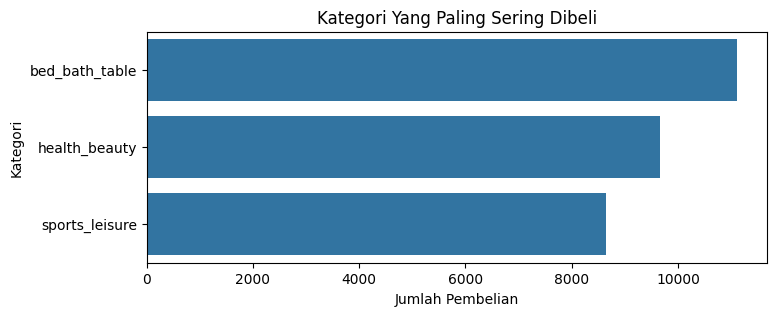

In [142]:
plt.figure(figsize=(8,3))
sns.barplot(data=top_3, x='total', y='category')
plt.title('Kategori Yang Paling Sering Dibeli')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Kategori')
plt.show()

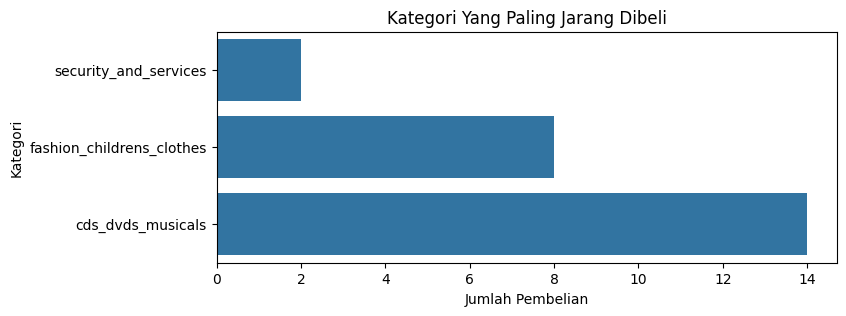

In [143]:
plt.figure(figsize=(8,3))
sns.barplot(data=bottom_3, x='total', y='category')
plt.title('Kategori Yang Paling Jarang Dibeli')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Kategori')
plt.show()

### Pertanyaan 2:Berapa rata-rata jumlah produk dalam satu pesanan?

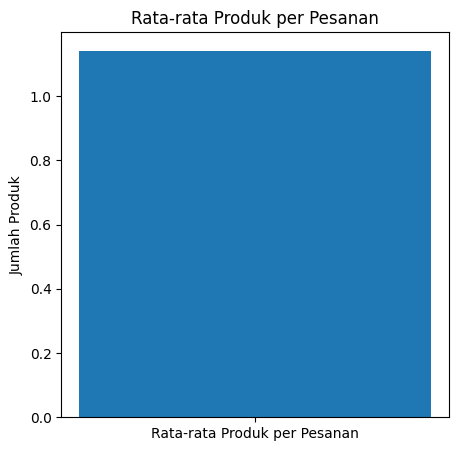

In [144]:
plt.figure(figsize=(5,5))
plt.bar(['Rata-rata Produk per Pesanan'], [avg_items])
plt.title('Rata-rata Produk per Pesanan')
plt.ylabel('Jumlah Produk')
plt.show()

### Pertanyaan 3:Berapa rata-rata total nilai transaksi  dalam satu pesanan setiap bulan? 

In [145]:
avg_monthly['month'] = avg_monthly['month'].astype(str)

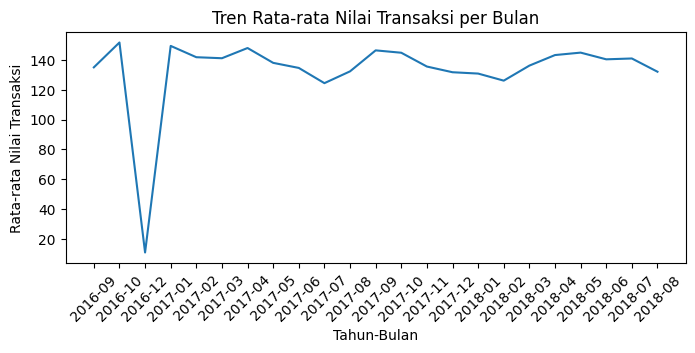

In [146]:
plt.figure(figsize=(8,3))
sns.lineplot(data=avg_monthly, x='month', y='price')

plt.xticks(rotation=45)
plt.title('Tren Rata-rata Nilai Transaksi per Bulan')
plt.xlabel('Tahun-Bulan')
plt.ylabel('Rata-rata Nilai Transaksi')

plt.show()

**Insight:** (Opsional)


## Simpan main_data

In [147]:
df.to_csv('main_data.csv', index=False)

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** kategori produk yang sering dibeli secara berurutan dari terbanyak adalah 'bed_bath_table', 'health_beauty' dan 'sports_leisure'. Kategori produk yang jarang dibeli secara berurutan dari yang paling sedikit adalah 'security_and_services', 'fashion_childrens_clothes' dan 'cds_dvds_musicals'

- **Conclusion pertanyaan 2:** Rata-rata jumlah produk dalam satu pesanan adalah 1.14 yang mana artinya customer cenderung berbelanja 1 produk saja setiap melakukan pemesanan. 

- **Conclusion pertanyaan 3:** Berdasarkan tren dari visualisasi di atas,  rata-rata nilai transaksi per bulan mengalami fluktuasi dari waktu ke waktu yang mungkin dipengaruhi oleh banyak faktor. Nilai tranksaksi paling besar terjadi pada bulan Oktober 2016 dan paling kecil pada Juli 2017

**Rekomendasi Action Item:**
- Produk-produk yang dikategorikan sebagai kategori populer sering ditampilkan pada halaman utama
- Menambahkan fitur rekomendasi produk di halaman produk atau keranjang yang berhubungan atau yang sering dibeli bersamaan dengan produk yang ada di keranjang
- Pada produk dengan kategori jarang dibeli, bisa dilakukan diskon atau bundling dengan produk pada produk kategori lain
- pada bulan dengan nilai tranksaksi yang cenderung rendah dapat dilakukan promosi yang lebih gencar dari bulan yang lain 